In [2]:
from google.colab import files
uploaded = files.upload()


Saving Loan_Default.csv to Loan_Default.csv


In [3]:
import pandas as pd
df = pd.read_csv("Loan_Default.csv")
print(df.shape)
df.head()


(148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


Dataset shape: (148670, 34)

Final Pipeline Accuracy: 0.8428

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90     22406
           1       0.76      0.53      0.63      7328

    accuracy                           0.84     29734
   macro avg       0.81      0.74      0.76     29734
weighted avg       0.84      0.84      0.83     29734


Confusion Matrix:
 [[21147  1259]
 [ 3416  3912]]


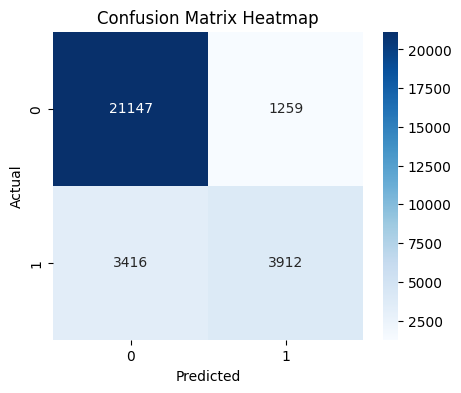

In [3]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Loan_Default.csv")
print("Dataset shape:", df.shape)

for col in ["age", "income", "loan_amount", "Credit_Score", "dtir1"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.fillna(df.median(numeric_only=True), inplace=True)

def feature_engineering(df):
    df = df.copy()

    if "age" in df.columns:
        df['AgeGroup'] = pd.cut(df['age'].astype(float),
                                bins=[0, 30, 50, 100],
                                labels=['Young', 'Middle', 'Senior'])
    else:
        df['AgeGroup'] = "Unknown"

    if "income" in df.columns:
        df['IncomeGroup'] = pd.qcut(df['income'], q=3, labels=['Low', 'Medium', 'High'])
    else:
        df['IncomeGroup'] = "Unknown"

    colname = "loan_purpose" if "loan_purpose" in df.columns else "LoanPurpose"
    if colname in df.columns:
        counts = df[colname].value_counts()
        rare_categories = counts[counts < 100].index
        df['LoanPurpose_mod'] = df[colname].replace(rare_categories, 'Other')
    else:
        df['LoanPurpose_mod'] = "Other"

    if "loan_amount" in df.columns and "income" in df.columns:
        df['LoanToIncome'] = df['loan_amount'] / (df['income'] + 1)
    else:
        df['LoanToIncome'] = 0

    if "dtir1" in df.columns and "Credit_Score" in df.columns:
        df['EmpScore'] = df['dtir1'] * df['Credit_Score']
    else:
        df['EmpScore'] = 0

    return df

feat_eng_transformer = FunctionTransformer(feature_engineering)

target = "Status"
X = df.drop(columns=[target])
y = df[target]

numeric_features = ['income', 'loan_amount', 'Credit_Score', 'dtir1',
                    'LoanToIncome', 'EmpScore']
categorical_features = ['AgeGroup', 'IncomeGroup', 'LoanPurpose_mod',
                        'Gender', 'loan_type', 'loan_purpose', 'Region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), [col for col in numeric_features if col in df.columns]),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         [col for col in categorical_features if col in X.columns])
    ])

pipeline = Pipeline(steps=[
    ('features', feat_eng_transformer),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nFinal Pipeline Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
